## General

In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

/Users/luyiming/Projects/edinet-agentic/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("SakanaAI/EDINET-Bench", "fraud_detection", split="test")

In [3]:
# Basic overview
print(f"Rows: {len(ds):,}")
print(f"Columns ({len(ds.column_names)}): {ds.column_names}")

feature_df = pd.DataFrame(ds.features.items(), columns=["column", "feature_type"])
display(feature_df)


Rows: 224
Columns (12): ['meta', 'summary', 'bs', 'pl', 'cf', 'text', 'label', 'explanation', 'edinet_code', 'ammended_doc_id', 'doc_id', 'file_path']


,column,feature_type
0,meta,Value('string')
1,summary,Value('string')
2,bs,Value('string')
3,pl,Value('string')
4,cf,Value('string')
5,text,Value('string')
6,label,Value('int64')
7,explanation,Value('string')
8,edinet_code,Value('string')
9,ammended_doc_id,Value('string')


In [4]:
# Data quality quick check
from pandas.api.types import is_string_dtype

df = ds.to_pandas()

# 1) Missing and empty-string rate by column
missing_rows = []
for col in df.columns:
    s = df[col]
    na_count = s.isna().sum()
    if is_string_dtype(s):
        empty_count = s.fillna("").str.strip().eq("").sum()
    else:
        empty_count = 0
    missing_rows.append(
        {
            "column": col,
            "na_count": int(na_count),
            "empty_str_count": int(empty_count),
            "total_missing_like": int(na_count + empty_count),
            "missing_like_ratio": (na_count + empty_count) / len(df),
        }
    )

missing_df = pd.DataFrame(missing_rows).sort_values("missing_like_ratio", ascending=False)
display(missing_df)

# 2) Uniqueness of key ID columns
id_cols = ["doc_id", "ammended_doc_id", "file_path"]
id_stats = []
for col in id_cols:
    if col in df.columns:
        id_stats.append(
            {
                "column": col,
                "n_unique": int(df[col].nunique(dropna=False)),
                "duplicate_rows": int(df[col].duplicated(keep=False).sum()),
            }
        )
display(pd.DataFrame(id_stats))

# 3) Label distribution
label_dist = df["label"].value_counts(dropna=False).sort_index()
label_ratio = df["label"].value_counts(normalize=True, dropna=False).sort_index()
label_table = pd.DataFrame({"count": label_dist, "ratio": label_ratio})
display(label_table)

# 4) Random sample for manual inspection
sample_cols = [c for c in ["label", "summary", "text", "explanation", "doc_id"] if c in df.columns]
display(df[sample_cols].sample(3, random_state=42))


,column,na_count,empty_str_count,total_missing_like,missing_like_ratio
7,explanation,0,222,222,0.991071
9,ammended_doc_id,0,222,222,0.991071
0,meta,0,0,0,0.000000
1,summary,0,0,0,0.000000
2,bs,0,0,0,0.000000
3,pl,0,0,0,0.000000
4,cf,0,0,0,0.000000
5,text,0,0,0,0.000000
6,label,0,0,0,0.000000
8,edinet_code,0,0,0,0.000000


,column,n_unique,duplicate_rows
0,doc_id,224,0
1,ammended_doc_id,3,222
2,file_path,224,0


,count,ratio
label,,
0,102,0.455357
1,122,0.544643


,label,summary,text,explanation,doc_id
9,0,"{""売上高"": {""Prior4Year"": ""573525000000"", ""Prior3Year"": ""545723000000"", ""Prior2Year"": ""531103000000"", ""Prior1Year"": ""40...","{""沿革"": {""FilingDate"": ""２【沿革】1919年11月 各種ソースならびに加工食料品の製造を目的として、東京都中野区小滝町に食品工業株式会社として設立される。1925年３月 キユーピーマヨネーズの製造を開始する...",,S100QA5X
84,1,"{""売上高"": {""Prior4Year"": ""28034000000"", ""Prior3Year"": ""30523000000"", ""Prior2Year"": ""29937000000"", ""Prior1Year"": ""29076...","{""沿革"": {""FilingDate"": "" ２ 【沿革】 1939年１月ラサ工業株式会社の製品を販売する目的を以て、資本金10万円で東京都中央区京橋にラサ商事株式会社を設立。1945年12月大阪支店を開設。1950年２月本社を東...",,S100G87J
117,1,"{""売上高"": {""Prior4Year"": ""5659874000"", ""Prior3Year"": ""11329952000"", ""Prior2Year"": ""11815722000"", ""Prior1Year"": ""115078...","{""沿革"": {""FilingDate"": "" ２ 【沿革】 年月事項1982年４月西麻布に「ひらまつ亭」開店1983年６月有限会社ひらまつ亭(出資金10,000千円)設立1988年５月広尾に「ひらまつ亭」を移転し、「レストランひら...",,S100D5Z5


In [5]:
import json

# Text length distribution and JSON parseability
text_cols = [c for c in ["meta", "summary", "bs", "pl", "cf", "text", "explanation"] if c in df.columns]

length_stats = []
json_stats = []

for col in text_cols:
    s = df[col].astype(str)
    lens = s.str.len()
    length_stats.append(
        {
            "column": col,
            "min_len": int(lens.min()),
            "p50_len": float(lens.quantile(0.50)),
            "p90_len": float(lens.quantile(0.90)),
            "p99_len": float(lens.quantile(0.99)),
            "max_len": int(lens.max()),
            "mean_len": float(lens.mean()),
        }
    )

    parsed_ok = 0
    for x in s:
        try:
            json.loads(x)
            parsed_ok += 1
        except Exception:
            pass
    json_stats.append(
        {
            "column": col,
            "json_parseable_count": parsed_ok,
            "json_parseable_ratio": parsed_ok / len(s),
        }
    )

length_df = pd.DataFrame(length_stats).sort_values("p90_len", ascending=False)
json_df = pd.DataFrame(json_stats).sort_values("json_parseable_ratio", ascending=False)

display(length_df)
display(json_df)


,column,min_len,p50_len,p90_len,p99_len,max_len,mean_len
5,text,15080,36812.0,49370.5,69700.93,81729,37527.959821
2,bs,898,3206.5,3847.1,4144.40,4273,3014.830357
1,summary,628,2546.5,2642.7,2711.77,2744,2418.352679
4,cf,459,1937.0,2194.1,2342.93,2394,1817.424107
3,pl,441,1462.5,1681.1,1772.85,1800,1388.066964
0,meta,241,253.0,259.0,284.54,294,254.433036
6,explanation,0,0.0,0.0,0.00,407,3.419643


,column,json_parseable_count,json_parseable_ratio
0,meta,224,1.0
1,summary,224,1.0
2,bs,224,1.0
3,pl,224,1.0
4,cf,224,1.0
5,text,224,1.0
6,explanation,0,0.0


,column,label,count,mean_len,p50_len,p90_len
4,bs,0,102,2906.382353,3139.5,3756.0
5,bs,1,122,3105.500000,3299.0,3871.5
8,cf,0,102,1782.980392,1872.0,2200.6
9,cf,1,122,1846.221311,1945.0,2153.9
0,meta,0,102,253.911765,253.0,258.9
1,meta,1,122,254.868852,252.0,259.0
6,pl,0,102,1362.254902,1471.0,1679.4
7,pl,1,122,1409.647541,1461.5,1678.4
2,summary,0,102,2395.941176,2533.0,2653.6
3,summary,1,122,2437.090164,2554.5,2631.9


<Figure size 700x400 with 0 Axes>

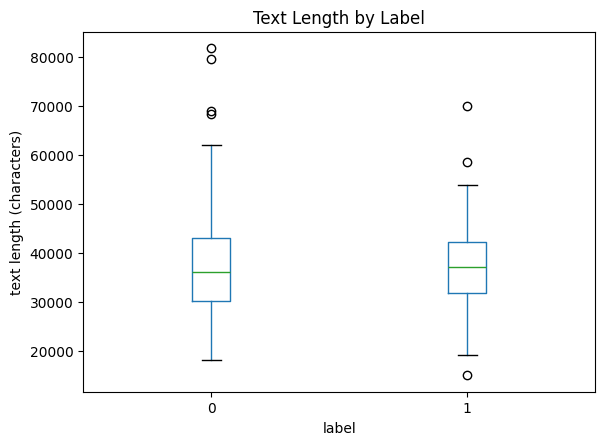

In [6]:
# Length comparison by label
cols_for_length = [c for c in ["meta", "summary", "bs", "pl", "cf", "text"] if c in df.columns]

for col in cols_for_length:
    df[f"{col}_len"] = df[col].fillna("").astype(str).str.len()

rows = []
for col in cols_for_length:
    for label_value, g in df.groupby("label"):
        s = g[f"{col}_len"]
        rows.append(
            {
                "column": col,
                "label": int(label_value),
                "count": int(len(s)),
                "mean_len": float(s.mean()),
                "p50_len": float(s.quantile(0.50)),
                "p90_len": float(s.quantile(0.90)),
            }
        )

length_by_label_df = pd.DataFrame(rows).sort_values(["column", "label"])
display(length_by_label_df)

plt.figure(figsize=(7, 4))
df.boxplot(column="text_len", by="label", grid=False)
plt.title("Text Length by Label")
plt.suptitle("")
plt.xlabel("label")
plt.ylabel("text length (characters)")
plt.show()


In [7]:
# Uniqueness check for edinet_code
col = "edinet_code"

n_rows = len(df)
n_unique = df[col].nunique(dropna=False)
n_duplicated_rows = df[col].duplicated(keep=False).sum()

print(f"Rows: {n_rows}")
print(f"Unique {col}: {n_unique}")
print(f"Uniqueness ratio: {n_unique / n_rows:.4f}")
print(f"Rows involved in duplicates: {n_duplicated_rows}")

code_freq = df[col].value_counts(dropna=False)
display(code_freq.head(10).to_frame(name="count"))


Rows: 224
Unique edinet_code: 151
Uniqueness ratio: 0.6741
Rows involved in duplicates: 105


,count
edinet_code,
E01587,6
E00897,5
E30481,5
E01094,4
E01874,4
E02181,4
E02547,4
E03044,4
E03314,4


In [8]:
# Inspect rows sharing the same edinet_code
dup_codes = df["edinet_code"].value_counts()
dup_codes = dup_codes[dup_codes > 1].head(3).index.tolist()
print("Selected duplicated edinet_code values:", dup_codes)

view_cols = [
    c for c in [
        "edinet_code", "doc_id", "ammended_doc_id", "label", "file_path",
        "meta", "summary", "explanation"
    ]
    if c in df.columns
]

for code in dup_codes:
    print(f"\n=== edinet_code: {code} ===")
    sub = df[df["edinet_code"] == code].sort_values("doc_id")
    show_df = sub[view_cols].copy()
    for c in ["meta", "summary", "explanation"]:
        if c in show_df.columns:
            show_df[c] = show_df[c].fillna("").astype(str).str.slice(0, 160)
    display(show_df)


Selected duplicated edinet_code values: ['E01587', 'E00897', 'E30481']

=== edinet_code: E01587 ===


,edinet_code,doc_id,ammended_doc_id,label,file_path,meta,summary,explanation
53,E01587,S100AB70,,1,v5/fraud/annual/S100AB70.tsv,"{""会社名"": ""株式会社東京衡機"", ""EDINETコード"": ""E01587"", ""ファンドコード"": ""－"", ""証券コード"": ""77190"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""4773366000"", ""Prior3Year"": ""5772490000"", ""Prior2Year"": ""5837981000"", ""Prior1Year"": ""48008560...",
51,E01587,S100FV80,,1,v5/fraud/annual/S100FV80.tsv,"{""会社名"": ""株式会社東京衡機"", ""EDINETコード"": ""E01587"", ""ファンドコード"": ""－"", ""証券コード"": ""77190"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""5837981000"", ""Prior3Year"": ""4800856000"", ""Prior2Year"": ""4988529000"", ""Prior1Year"": ""45270010...",
52,E01587,S100INCU,,1,v5/fraud/annual/S100INCU.tsv,"{""会社名"": ""株式会社東京衡機"", ""EDINETコード"": ""E01587"", ""ファンドコード"": ""－"", ""証券コード"": ""77190"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""4800856000"", ""Prior3Year"": ""4988529000"", ""Prior2Year"": ""4527001000"", ""Prior1Year"": ""53796290...",
54,E01587,S100LEWC,,1,v5/fraud/annual/S100LEWC.tsv,"{""会社名"": ""株式会社東京衡機"", ""EDINETコード"": ""E01587"", ""ファンドコード"": ""－"", ""証券コード"": ""77190"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""4988529000"", ""Prior3Year"": ""4527001000"", ""Prior2Year"": ""5379629000"", ""Prior1Year"": ""74396560...",
55,E01587,S100O4G9,,1,v5/fraud/annual/S100O4G9.tsv,"{""会社名"": ""株式会社東京衡機"", ""EDINETコード"": ""E01587"", ""ファンドコード"": ""－"", ""証券コード"": ""77190"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""4527001000"", ""Prior3Year"": ""5379629000"", ""Prior2Year"": ""7439656000"", ""Prior1Year"": ""83211870...",
50,E01587,S100QTT7,,1,v5/fraud/annual/S100QTT7.tsv,"{""会社名"": ""株式会社東京衡機"", ""EDINETコード"": ""E01587"", ""ファンドコード"": ""－"", ""証券コード"": ""77190"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""5318236000"", ""Prior3Year"": ""4825136000"", ""Prior2Year"": ""3867733000"", ""Prior1Year"": ""40391930...",



=== edinet_code: E00897 ===


,edinet_code,doc_id,ammended_doc_id,label,file_path,meta,summary,explanation
38,E00897,S100AGPO,,1,v5/fraud/annual/S100AGPO.tsv,"{""会社名"": ""中国塗料株式会社"", ""EDINETコード"": ""E00897"", ""ファンドコード"": ""－"", ""証券コード"": ""46170"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""83656000000"", ""Prior3Year"": ""90901000000"", ""Prior2Year"": ""106737000000"", ""Prior1Year"": ""1150...",
35,E00897,S100D1XI,,1,v5/fraud/annual/S100D1XI.tsv,"{""会社名"": ""中国塗料株式会社"", ""EDINETコード"": ""E00897"", ""ファンドコード"": ""－"", ""証券コード"": ""46170"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""90901000000"", ""Prior3Year"": ""106737000000"", ""Prior2Year"": ""115066000000"", ""Prior1Year"": ""823...",
36,E00897,S100G1ZM,,1,v5/fraud/annual/S100G1ZM.tsv,"{""会社名"": ""中国塗料株式会社"", ""EDINETコード"": ""E00897"", ""ファンドコード"": ""－"", ""証券コード"": ""46170"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""106737000000"", ""Prior3Year"": ""115066000000"", ""Prior2Year"": ""82368000000"", ""Prior1Year"": ""829...",
37,E00897,S100IY7G,,1,v5/fraud/annual/S100IY7G.tsv,"{""会社名"": ""中国塗料株式会社"", ""EDINETコード"": ""E00897"", ""ファンドコード"": ""－"", ""証券コード"": ""46170"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""115066000000"", ""Prior3Year"": ""82368000000"", ""Prior2Year"": ""82980000000"", ""Prior1Year"": ""8845...",
39,E00897,S100LN04,,1,v5/fraud/annual/S100LN04.tsv,"{""会社名"": ""中国塗料株式会社"", ""EDINETコード"": ""E00897"", ""ファンドコード"": ""－"", ""証券コード"": ""46170"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan GAAP""...","{""売上高"": {""Prior4Year"": ""82368000000"", ""Prior3Year"": ""82980000000"", ""Prior2Year"": ""88452000000"", ""Prior1Year"": ""87729...",



=== edinet_code: E30481 ===


,edinet_code,doc_id,ammended_doc_id,label,file_path,meta,summary,explanation
182,E30481,S10050OO,,1,v5/fraud/annual/S10050OO.tsv,"{""会社名"": ""株式会社ジャパンディスプレイ"", ""EDINETコード"": ""E30481"", ""ファンドコード"": ""－"", ""証券コード"": ""67400"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan...","{""売上高"": {""Prior4Year"": ""－"", ""Prior3Year"": ""133974000000"", ""Prior2Year"": ""165144000000"", ""Prior1Year"": ""614567000000""...",
183,E30481,S1007SQZ,,1,v5/fraud/annual/S1007SQZ.tsv,"{""会社名"": ""株式会社ジャパンディスプレイ"", ""EDINETコード"": ""E30481"", ""ファンドコード"": ""－"", ""証券コード"": ""67400"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan...","{""売上高"": {""Prior4Year"": ""133974000000"", ""Prior3Year"": ""165144000000"", ""Prior2Year"": ""614567000000"", ""Prior1Year"": ""76...",
186,E30481,S100AHZT,,1,v5/fraud/annual/S100AHZT.tsv,"{""会社名"": ""株式会社ジャパンディスプレイ"", ""EDINETコード"": ""E30481"", ""ファンドコード"": ""－"", ""証券コード"": ""67400"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan...","{""売上高"": {""Prior4Year"": ""165144000000"", ""Prior3Year"": ""614567000000"", ""Prior2Year"": ""769304000000"", ""Prior1Year"": ""98...",
184,E30481,S100D87L,,1,v5/fraud/annual/S100D87L.tsv,"{""会社名"": ""株式会社ジャパンディスプレイ"", ""EDINETコード"": ""E30481"", ""ファンドコード"": ""－"", ""証券コード"": ""67400"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan...","{""売上高"": {""Prior4Year"": ""614567000000"", ""Prior3Year"": ""769304000000"", ""Prior2Year"": ""989115000000"", ""Prior1Year"": ""88...",
185,E30481,S100G1VU,,1,v5/fraud/annual/S100G1VU.tsv,"{""会社名"": ""株式会社ジャパンディスプレイ"", ""EDINETコード"": ""E30481"", ""ファンドコード"": ""－"", ""証券コード"": ""67400"", ""提出書類"": ""有価証券報告書"", ""会計基準"": ""Japan...","{""売上高"": {""Prior4Year"": ""769304000000"", ""Prior3Year"": ""989115000000"", ""Prior2Year"": ""884440000000"", ""Prior1Year"": ""71...",


`edinet_code` is the identifier of the company.

## Detailed Inspection

In [9]:
import json

# Refactor helpers for JSON-like columns
def inspect_json_column(df, col, key_name, preview_chars=None):
    parsed = df[col].apply(json.loads)

    # 1) Example
    example_idx = parsed.index[0]
    print("Example row index:", example_idx)
    example_obj = parsed.iloc[0]

    if preview_chars is None:
        display(example_obj)
    else:
        rows = []
        for k, v in example_obj.items():
            rows.append({key_name: k, "preview": str(v)[:preview_chars]})
        display(pd.DataFrame(rows))

    # 2) Top-level keys
    top_keys = sorted(set().union(*parsed.map(dict.keys)))
    print("\nNumber of top-level keys:", len(top_keys))
    display(pd.DataFrame({key_name: top_keys}))

    # 3) Type overview
    type_rows = []
    for k in top_keys:
        v = next((d.get(k) for d in parsed if d.get(k) is not None), None)
        type_rows.append({key_name: k, "python_type": type(v).__name__})
    display(pd.DataFrame(type_rows).sort_values(key_name))

    return parsed, top_keys


def coverage_json_column(parsed, top_keys, key_name):
    n_samples = len(parsed)

    # 1) Coverage per key
    coverage_rows = []
    for k in top_keys:
        present_count = int(parsed.map(lambda d: k in d).sum())
        coverage_rows.append(
            {
                key_name: k,
                "present_count": present_count,
                "coverage_ratio": present_count / n_samples,
            }
        )

    coverage_df = pd.DataFrame(coverage_rows).sort_values(
        ["coverage_ratio", "present_count", key_name],
        ascending=[False, False, True],
    )
    display(coverage_df)

    # 2) Number of keys per sample
    key_count_per_sample = parsed.map(len)
    sample_keycount_df = key_count_per_sample.describe(
        percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
    ).to_frame(name=f"num_{key_name}s")
    display(sample_keycount_df)

    # 3) Unified-key quick answer
    all_full = bool((coverage_df["present_count"] == n_samples).all())
    print(f"All samples share exactly the same {key_name} set: {all_full}")
    print(f"Total unique {key_name}s (union): {len(top_keys)}")
    print(f"{key_name}s present in all samples (intersection size): {(coverage_df['present_count'] == n_samples).sum()}")

    return coverage_df, sample_keycount_df

### `meta`

In [10]:
meta_parsed_ref, meta_top_keys_ref = inspect_json_column(df, "meta", "meta_key")
_ = coverage_json_column(meta_parsed_ref, meta_top_keys_ref, "meta_key")

Example row index: 0


{'会社名': '古河機械金属株式会社',
 'EDINETコード': 'E00032',
 'ファンドコード': '－',
 '証券コード': '57150',
 '提出書類': '有価証券報告書',
 '会計基準': 'Japan GAAP',
 '当事業年度開始日': '2020-04-01',
 '当事業年度終了日': '2021-03-31',
 '連結決算の有無': 'true',
 '修正の有無': 'false',
 '記載事項訂正のフラグ': 'false',
 'XBRL訂正のフラグ': 'false'}


Number of top-level keys: 12


,meta_key
0,EDINETコード
1,XBRL訂正のフラグ
2,ファンドコード
3,会社名
4,会計基準
5,修正の有無
6,当事業年度終了日
7,当事業年度開始日
8,提出書類
9,記載事項訂正のフラグ


,meta_key,python_type
0,EDINETコード,str
1,XBRL訂正のフラグ,str
2,ファンドコード,str
3,会社名,str
4,会計基準,str
5,修正の有無,str
6,当事業年度終了日,str
7,当事業年度開始日,str
8,提出書類,str
9,記載事項訂正のフラグ,str


,meta_key,present_count,coverage_ratio
0,EDINETコード,224,1.0
1,XBRL訂正のフラグ,224,1.0
2,ファンドコード,224,1.0
3,会社名,224,1.0
4,会計基準,224,1.0
5,修正の有無,224,1.0
6,当事業年度終了日,224,1.0
7,当事業年度開始日,224,1.0
8,提出書類,224,1.0
9,記載事項訂正のフラグ,224,1.0


,num_meta_keys
count,224.0
mean,12.0
std,0.0
min,12.0
10%,12.0
25%,12.0
50%,12.0
75%,12.0
90%,12.0
max,12.0


All samples share exactly the same meta_key set: True
Total unique meta_keys (union): 12
meta_keys present in all samples (intersection size): 12


In [11]:
# Value distributions for the last four meta fields
last_four_keys = [
    "連結決算の有無",
    "修正の有無",
    "記載事項訂正のフラグ",
    "XBRL訂正のフラグ",
]

dist_rows = []
for k in last_four_keys:
    s = meta_parsed_ref.map(lambda d: d.get(k, None))
    count_s = s.value_counts(dropna=False)
    ratio_s = s.value_counts(dropna=False, normalize=True)
    for v in count_s.index:
        dist_rows.append(
            {
                "meta_key": k,
                "value": v,
                "count": int(count_s[v]),
                "ratio": float(ratio_s[v]),
            }
        )

dist_df = pd.DataFrame(dist_rows).sort_values(["meta_key", "count"], ascending=[True, False])
display(dist_df)


,meta_key,value,count,ratio
5,XBRL訂正のフラグ,false,224,1.000000
1,修正の有無,false,222,0.991071
2,修正の有無,true,2,0.008929
3,記載事項訂正のフラグ,false,222,0.991071
4,記載事項訂正のフラグ,true,2,0.008929
0,連結決算の有無,true,224,1.000000


In [12]:
# Inspect suspicious samples (true flags in amendment/correction fields)
flag_keys = ["修正の有無", "記載事項訂正のフラグ"]

is_suspicious = meta_parsed_ref.map(lambda d: any(d.get(k) == "true" for k in flag_keys))
sus_idx = df.index[is_suspicious].tolist()

print(f"Suspicious sample count (union): {len(sus_idx)}")
print("Indices:", sus_idx)

base_cols = [
    c for c in ["doc_id", "edinet_code", "label", "ammended_doc_id", "file_path"]
    if c in df.columns
]

flag_df = pd.DataFrame([
    {
        "index": i,
        "修正の有無": meta_parsed_ref.iloc[i].get("修正の有無"),
        "記載事項訂正のフラグ": meta_parsed_ref.iloc[i].get("記載事項訂正のフラグ"),
        "XBRL訂正のフラグ": meta_parsed_ref.iloc[i].get("XBRL訂正のフラグ"),
    }
    for i in sus_idx
])

overview_df = df.loc[sus_idx, base_cols].reset_index().rename(columns={"index": "row_index"})
overview_df = overview_df.merge(flag_df, left_on="row_index", right_on="index", how="left").drop(columns=["index"])
display(overview_df)

for i in sus_idx:
    print(f"\n=== row_index: {i} | doc_id: {df.loc[i, 'doc_id']} ===")
    display(meta_parsed_ref.iloc[i])


Suspicious sample count (union): 2
Indices: [188, 208]


,row_index,doc_id,edinet_code,label,ammended_doc_id,file_path,修正の有無,記載事項訂正のフラグ,XBRL訂正のフラグ
0,188,S100DNCW,E30993,1,S100DNCW,v5/fraud/annual/S100DNCW.tsv,true,true,false
1,208,S100TF6W,E35124,1,S100TF6W,v5/fraud/annual/S100TF6W.tsv,true,true,false



=== row_index: 188 | doc_id: S100DNCW ===


{'会社名': '株式会社エムケイシステム',
 'EDINETコード': 'E30993',
 'ファンドコード': '－',
 '証券コード': '39100',
 '提出書類': '有価証券報告書（平成30年６月29日付け訂正報告書の添付インラインXBRL)',
 '会計基準': 'Japan GAAP',
 '当事業年度開始日': '2017-04-01',
 '当事業年度終了日': '2018-03-31',
 '連結決算の有無': 'true',
 '修正の有無': 'true',
 '記載事項訂正のフラグ': 'true',
 'XBRL訂正のフラグ': 'false'}


=== row_index: 208 | doc_id: S100TF6W ===


{'会社名': 'Chatwork株式会社',
 'EDINETコード': 'E35124',
 'ファンドコード': '－',
 '証券コード': '44480',
 '提出書類': '有価証券報告書（2024年５月15日付け訂正報告書の添付インラインXBRL）',
 '会計基準': 'Japan GAAP',
 '当事業年度開始日': '2023-01-01',
 '当事業年度終了日': '2023-12-31',
 '連結決算の有無': 'true',
 '修正の有無': 'true',
 '記載事項訂正のフラグ': 'true',
 'XBRL訂正のフラグ': 'false'}

In [13]:
# Inspect other columns for the suspicious two samples
text_cols = [c for c in ["summary", "bs", "pl", "cf", "text", "explanation"] if c in df.columns]
meta_cols = [c for c in ["doc_id", "edinet_code", "label", "ammended_doc_id", "file_path"] if c in df.columns]

# 1) Row preview across major columns
preview_cols = meta_cols + text_cols
preview_df = df.loc[sus_idx, preview_cols].copy()
for c in text_cols:
    preview_df[c] = preview_df[c].fillna("").astype(str).str.slice(0, 180)
display(preview_df)

# 2) Length profile vs full dataset median
rows = []
for i in sus_idx:
    for c in text_cols:
        sample_len = len(str(df.loc[i, c] if pd.notna(df.loc[i, c]) else ""))
        global_median = df[c].fillna("").astype(str).str.len().median()
        rows.append(
            {
                "row_index": i,
                "doc_id": df.loc[i, "doc_id"],
                "column": c,
                "sample_len": int(sample_len),
                "global_median_len": float(global_median),
                "len_ratio_vs_median": float(sample_len / global_median) if global_median > 0 else np.nan,
            }
        )

length_profile_df = pd.DataFrame(rows).sort_values(["doc_id", "column"])
display(length_profile_df)


,doc_id,edinet_code,label,ammended_doc_id,file_path,summary,bs,pl,cf,text,explanation
188,S100DNCW,E30993,1,S100DNCW,v5/fraud/annual/S100DNCW.tsv,"{""売上高"": {""Prior4Year"": ""－"", ""Prior3Year"": ""－"", ""Prior2Year"": ""－"", ""Prior1Year"": ""1600787000"", ""CurrentYear"": ""188726...","{""現金及び預金"": {""Prior1Year"": ""667536000"", ""CurrentYear"": ""720192000""}, ""現金及び現金同等物"": {""Prior2Year"": ""737931000"", ""Prior1...","{""売上高"": {""Prior1Year"": ""1600787000"", ""CurrentYear"": ""1887269000""}, ""売上原価"": {""Prior1Year"": ""675405000"", ""CurrentYear""...","{""当期利益"": {""Prior1Year"": ""198796000"", ""CurrentYear"": ""213180000""}, ""税引前当期純利益"": {""Prior1Year"": ""305478000"", ""CurrentYe...","{""沿革"": {""FilingDate"": "" ２ 【沿革】 年月概要平成元年２月大阪市天王寺区に株式会社エムケイ情報システムを資本金5,000千円で設立、商工業者団体向けの会員管理システム、会計システム、労働保険事務組合システム、...",この訂正有価証券報告書には会計不正の可能性を示す重要な情報が含まれています。特に以下の点が懸念されます：1) 「契約更新時の確認体制に関する内部統制に開示すべき重要な不備が存在している」という監査報告書の記述があり、内部統制の重大な...
208,S100TF6W,E35124,1,S100TF6W,v5/fraud/annual/S100TF6W.tsv,"{""売上高"": {""Prior4Year"": ""－"", ""Prior3Year"": ""－"", ""Prior2Year"": ""3372285000"", ""Prior1Year"": ""4593178000"", ""CurrentYear""...","{""現金及び預金"": {""Prior1Year"": ""2850323000"", ""CurrentYear"": ""2102487000""}, ""現金及び現金同等物"": {""Prior2Year"": ""3200053000"", ""Pri...","{""売上高"": {""Prior1Year"": ""4593178000"", ""CurrentYear"": ""6485207000""}, ""売上原価"": {""Prior1Year"": ""1405429000"", ""CurrentYear...","{""当期利益"": {""Prior1Year"": ""-725810000"", ""CurrentYear"": ""-700172000""}, ""税引前当期純利益"": {""Prior1Year"": ""-723795000"", ""Curren...","{""沿革"": {""FilingDate"": "" ２ 【沿革】 年月概要2000年７月企業向けのホームページ集客を支援するサービスの提供を目的として、大阪府吹田市にEC studioを創業2004年11月有限会社EC studioを設...",この訂正有価証券報告書は会計不正に関連していると判断できます。提出理由の部分に、「顧客関連資産について、2023年12月期決算において減損損失を計上すべきであったのではないかとの指摘を受けました」と記載されており、資産の評価に関する...


,row_index,doc_id,column,sample_len,global_median_len,len_ratio_vs_median
1,188,S100DNCW,bs,2349,3206.5,0.732574
3,188,S100DNCW,cf,1737,1937.0,0.896748
5,188,S100DNCW,explanation,407,0.0,NaN
2,188,S100DNCW,pl,1318,1462.5,0.901197
0,188,S100DNCW,summary,2220,2546.5,0.871785
4,188,S100DNCW,text,37644,36812.0,1.022601
7,208,S100TF6W,bs,2339,3206.5,0.729456
9,208,S100TF6W,cf,1822,1937.0,0.940630
11,208,S100TF6W,explanation,359,0.0,NaN
8,208,S100TF6W,pl,1505,1462.5,1.029060


### `summary`

In [14]:
summary_parsed_ref, summary_top_keys_ref = inspect_json_column(df, "summary", "summary_key")
_ = coverage_json_column(summary_parsed_ref, summary_top_keys_ref, "summary_key")

Example row index: 0


{'売上高': {'Prior4Year': '149829000000',
  'Prior3Year': '167695000000',
  'Prior2Year': '174116000000',
  'Prior1Year': '165215000000',
  'CurrentYear': '159702000000'},
 '経常利益': {'Prior4Year': '7202000000',
  'Prior3Year': '8105000000',
  'Prior2Year': '8235000000',
  'Prior1Year': '8135000000',
  'CurrentYear': '6773000000'},
 '親会社株主に帰属する当期純利益': {'Prior4Year': '4254000000',
  'Prior3Year': '4774000000',
  'Prior2Year': '4654000000',
  'Prior1Year': '4431000000',
  'CurrentYear': '7468000000'},
 '包括利益': {'Prior4Year': '13355000000',
  'Prior3Year': '9545000000',
  'Prior2Year': '-3388000000',
  'Prior1Year': '-60000000',
  'CurrentYear': '18543000000'},
 '純資産額': {'Prior4Year': '79584000000',
  'Prior3Year': '87086000000',
  'Prior2Year': '80447000000',
  'Prior1Year': '77966000000',
  'CurrentYear': '94364000000'},
 '総資産額': {'Prior4Year': '208034000000',
  'Prior3Year': '222211000000',
  'Prior2Year': '215368000000',
  'Prior1Year': '209697000000',
  'CurrentYear': '218275000000'},
 '１


Number of top-level keys: 22


,summary_key
0,包括利益
1,営業活動によるキャッシュ・フロー
2,売上高
3,平均臨時雇用人員
4,当期包括利益: 親会社の所有者に帰属（IFRS）
5,当期純利益又は当期純損失
6,従業員数
7,投資活動によるキャッシュ・フロー
8,株価収益率
9,潜在株式調整後１株当たり当期純利益


,summary_key,python_type
0,包括利益,dict
1,営業活動によるキャッシュ・フロー,dict
2,売上高,dict
3,平均臨時雇用人員,dict
4,当期包括利益: 親会社の所有者に帰属（IFRS）,dict
5,当期純利益又は当期純損失,dict
6,従業員数,dict
7,投資活動によるキャッシュ・フロー,dict
8,株価収益率,dict
9,潜在株式調整後１株当たり当期純利益,dict


,summary_key,present_count,coverage_ratio
6,従業員数,224,1.000000
0,包括利益,216,0.964286
1,営業活動によるキャッシュ・フロー,216,0.964286
7,投資活動によるキャッシュ・フロー,216,0.964286
10,現金及び現金同等物の残高,216,0.964286
12,純資産額,216,0.964286
13,経常利益,216,0.964286
14,総資産額,216,0.964286
15,自己資本利益率、経営指標等,216,0.964286
16,自己資本比率,216,0.964286


,num_summary_keys
count,224.000000
mean,17.285714
std,2.532050
min,4.000000
10%,17.000000
25%,17.000000
50%,18.000000
75%,18.000000
90%,18.000000
max,21.000000


All samples share exactly the same summary_key set: False
Total unique summary_keys (union): 22
summary_keys present in all samples (intersection size): 1


### `bs`

In [15]:
bs_parsed_ref, bs_top_keys_ref = inspect_json_column(df, "bs", "bs_key")
_ = coverage_json_column(bs_parsed_ref, bs_top_keys_ref, "bs_key")

Example row index: 0


{'現金及び預金': {'Prior1Year': '12647000000', 'CurrentYear': '17748000000'},
 '現金及び現金同等物': {'Prior2Year': '14217000000',
  'Prior1Year': '12646000000',
  'CurrentYear': '17748000000'},
 '受取手形及び売掛金': {'Prior1Year': '30653000000', 'CurrentYear': '28030000000'},
 '商品及び製品': {'Prior1Year': '16950000000', 'CurrentYear': '15990000000'},
 '仕掛品': {'Prior1Year': '10514000000', 'CurrentYear': '9839000000'},
 '原材料及び貯蔵品': {'Prior1Year': '10944000000', 'CurrentYear': '11589000000'},
 'その他': {'Prior1Year': '2261000000', 'CurrentYear': '2360000000'},
 '貸倒引当金': {'Prior1Year': '-163000000', 'CurrentYear': '-141000000'},
 '流動資産': {'Prior1Year': '85725000000', 'CurrentYear': '88625000000'},
 '建物及び構築物（純額）': {'Prior1Year': '23219000000', 'CurrentYear': '22540000000'},
 '機械装置及び運搬具（純額）': {'Prior1Year': '8131000000', 'CurrentYear': '9042000000'},
 '土地': {'Prior1Year': '53497000000', 'CurrentYear': '53436000000'},
 '建設仮勘定': {'Prior1Year': '1316000000', 'CurrentYear': '1271000000'},
 '減価償却累計額': {'Prior1Year': '-67005


Number of top-level keys: 83


,bs_key
0,その他
1,その他、投資その他の資産
2,その他、有形固定資産
3,その他有価証券評価差額金
4,その他（純額）、有形固定資産
...,...
78,非支配株主持分
79,非流動負債
80,預り金
81,１年内償還予定の社債


,bs_key,python_type
0,その他,dict
1,その他、投資その他の資産,dict
2,その他、有形固定資産,dict
3,その他有価証券評価差額金,dict
4,その他（純額）、有形固定資産,dict
...,...,...
78,非支配株主持分,dict
79,非流動負債,dict
80,預り金,dict
81,１年内償還予定の社債,dict


,bs_key,present_count,coverage_ratio
7,利益剰余金,224,1.000000
28,有形固定資産,224,1.000000
46,現金及び現金同等物,224,1.000000
53,総資産,224,1.000000
61,負債,224,1.000000
...,...,...,...
25,支払手形,5,0.022321
34,構築物,3,0.013393
76,関係会社短期貸付金,3,0.013393
9,原材料,2,0.008929


,num_bs_keys
count,224.000000
mean,43.165179
std,10.563260
min,12.000000
10%,30.300000
25%,38.000000
50%,46.000000
75%,51.000000
90%,54.000000
max,61.000000


All samples share exactly the same bs_key set: False
Total unique bs_keys (union): 83
bs_keys present in all samples (intersection size): 6


### `cf`

In [16]:
cf_parsed_ref, cf_top_keys_ref = inspect_json_column(df, "cf", "cf_key")
_ = coverage_json_column(cf_parsed_ref, cf_top_keys_ref, "cf_key")

Example row index: 0


{'当期利益': {'Prior1Year': '4641000000', 'CurrentYear': '7670000000'},
 '税引前当期純利益': {'Prior1Year': '7280000000', 'CurrentYear': '9907000000'},
 '減価償却費及び償却費': {'Prior1Year': '3589000000', 'CurrentYear': '3879000000'},
 '受取利息及び受取配当金': {'Prior1Year': '-990000000', 'CurrentYear': '-929000000'},
 '支払利息': {'Prior1Year': '512000000', 'CurrentYear': '456000000'},
 '売上債権の増減額（△は増加）': {'Prior1Year': '-16000000', 'CurrentYear': '2550000000'},
 '棚卸資産の増減額（△は増加）': {'Prior1Year': '207000000', 'CurrentYear': '645000000'},
 '仕入債務の増減額（△は減少）': {'Prior1Year': '-5084000000', 'CurrentYear': '-1259000000'},
 'その他': {'Prior1Year': '-442000000', 'CurrentYear': '-187000000'},
 '利息及び配当金の受取額': {'Prior1Year': '1036000000', 'CurrentYear': '1004000000'},
 '利息の支払額': {'Prior1Year': '-512000000', 'CurrentYear': '-462000000'},
 '法人税等の支払額': {'Prior1Year': '-2160000000', 'CurrentYear': '-1863000000'},
 '営業キャッシュフロー': {'Prior1Year': '8400000000', 'CurrentYear': '6042000000'},
 '投資有価証券の売却による収入': {'Prior1Year': '350000000', 'Curr


Number of top-level keys: 39


,cf_key
0,その他
1,ファイナンス・リース債務の返済による支出
2,仕入債務の増減額（△は減少）
3,利息の支払額
4,利息及び配当金の受取額
5,前受金の増減額（△は減少）
6,受取利息及び受取配当金
7,営業キャッシュフロー
8,固定資産売却損益（△は益）
9,売上債権の増減額（△は増加）


,cf_key,python_type
0,その他,dict
1,ファイナンス・リース債務の返済による支出,dict
2,仕入債務の増減額（△は減少）,dict
3,利息の支払額,dict
4,利息及び配当金の受取額,dict
5,前受金の増減額（△は減少）,dict
6,受取利息及び受取配当金,dict
7,営業キャッシュフロー,dict
8,固定資産売却損益（△は益）,dict
9,売上債権の増減額（△は増加）,dict


,cf_key,present_count,coverage_ratio
7,営業キャッシュフロー,224,1.000000
11,投資キャッシュフロー,224,1.000000
21,現金及び現金同等物,224,1.000000
31,財務キャッシュフロー,224,1.000000
23,現金及び現金同等物の増減額,219,0.977679
19,減価償却費及び償却費,216,0.964286
28,税引前当期純利益,210,0.937500
0,その他,203,0.906250
17,棚卸資産の増減額（△は増加）,200,0.892857
9,売上債権の増減額（△は増加）,198,0.883929


,num_cf_keys
count,224.000000
mean,24.196429
std,5.313219
min,6.000000
10%,18.000000
25%,23.000000
50%,25.000000
75%,28.000000
90%,29.000000
max,32.000000


All samples share exactly the same cf_key set: False
Total unique cf_keys (union): 39
cf_keys present in all samples (intersection size): 4


### `pl`

In [17]:
pl_parsed_ref, pl_top_keys_ref = inspect_json_column(df, "pl", "pl_key")
_ = coverage_json_column(pl_parsed_ref, pl_top_keys_ref, "pl_key")

Example row index: 0


{'売上高': {'Prior1Year': '165215000000', 'CurrentYear': '159702000000'},
 '売上原価': {'Prior1Year': '138940000000', 'CurrentYear': '137508000000'},
 '売上総利益又は売上総損失（△)': {'Prior1Year': '26275000000',
  'CurrentYear': '22194000000'},
 '販売費及び一般管理費': {'Prior1Year': '17582000000', 'CurrentYear': '16601000000'},
 '営業利益': {'Prior1Year': '8693000000', 'CurrentYear': '5592000000'},
 '受取利息': {'Prior1Year': '218000000', 'CurrentYear': '179000000'},
 '受取配当金': {'Prior1Year': '772000000', 'CurrentYear': '749000000'},
 '為替差益': {'Prior1Year': '－', 'CurrentYear': '702000000'},
 'その他': {'Prior1Year': '382000000', 'CurrentYear': '89000000'},
 '営業外収益': {'Prior1Year': '1595000000', 'CurrentYear': '2749000000'},
 '支払利息': {'Prior1Year': '512000000', 'CurrentYear': '456000000'},
 '営業外費用': {'Prior1Year': '2153000000', 'CurrentYear': '1568000000'},
 '経常利益': {'Prior1Year': '8135000000', 'CurrentYear': '6773000000'},
 '投資有価証券売却益': {'Prior1Year': '20000000', 'CurrentYear': '4078000000'},
 '特別利益合計': {'Prior1Year': '70100


Number of top-level keys: 34


,pl_key
0,その他
1,一般管理費
2,受取利息
3,受取配当金
4,営業利益
5,営業外収益
6,営業外費用
7,固定資産売却益
8,売上原価
9,売上原価並びに販売費及び一般管理費合計


,pl_key,python_type
0,その他,dict
1,一般管理費,dict
2,受取利息,dict
3,受取配当金,dict
4,営業利益,dict
5,営業外収益,dict
6,営業外費用,dict
7,固定資産売却益,dict
8,売上原価,dict
9,売上原価並びに販売費及び一般管理費合計,dict


,pl_key,present_count,coverage_ratio
25,税引前利益,224,1.000000
4,営業利益,218,0.973214
30,販売費及び一般管理費,217,0.968750
16,法人所得税費用,210,0.937500
26,経常利益,210,0.937500
17,法人税、住民税及び事業税,209,0.933036
8,売上原価,207,0.924107
10,売上総利益又は売上総損失（△),207,0.924107
5,営業外収益,204,0.910714
6,営業外費用,204,0.910714


,num_pl_keys
count,224.000000
mean,20.888393
std,4.396396
min,6.000000
10%,15.300000
25%,20.000000
50%,22.000000
75%,23.250000
90%,25.000000
max,27.000000


All samples share exactly the same pl_key set: False
Total unique pl_keys (union): 34
pl_keys present in all samples (intersection size): 1


### `text`

In [18]:
text_parsed_ref, text_top_keys_ref = inspect_json_column(df, "text", "text_key", preview_chars=220)
_ = coverage_json_column(text_parsed_ref, text_top_keys_ref, "text_key")

Example row index: 0


,text_key,preview
0,沿革,{'FilingDate': '2【沿革】1875年 8月当社創業者古河市兵衛、草倉銅山（新潟県）を譲り受け、経営を開始。1877年 2月足尾銅山（栃木県）を譲り受ける。1894年 9月下山田炭鉱（福岡県）を譲り受け、石炭事業へ進出...
1,事業の内容,{'FilingDate': '3【事業の内容】\u3000当社グループ（当社および当社の関係会社）は、当社、子会社31社および関連会社11社で構成されております。主な事業は、古河産機システムズ㈱を中核事業会社とする産業機械部門、古...
2,関係会社の状況,{'FilingDate': '4【関係会社の状況】(1) 連結子会社名称住所資本金（百万円）主要な事業内容議決権の所有割合（%）関係内容古河産機システムズ㈱東京都千代田区300産業機械100経営管理・金銭貸借関係・業務委託関係役員...
3,従業員の状況,{'FilingDate': '5【従業員の状況】(1) 連結会社の状況 2021年3月31日現在セグメントの名称従業員数（人）産\u3000\u3000\u3000業\u3000\u3000\u3000機\u3000\u3000\...
4,経営方針、経営環境及び対処すべき課題等,{'FilingDate': '1【経営方針、経営環境及び対処すべき課題等】(1) 会社の経営の基本方針当社グループは、「古河機械金属グループは、鉱山開発に始まり社会基盤を支えてきた技術を進化させ、常に挑戦する気概をもって社会に必要...
5,事業等のリスク,{'FilingDate': '2【事業等のリスク】有価証券報告書に記載した事業の状況、経理の状況等に関する事項のうち、投資者の判断に重要な影響を及ぼす可能性のある事項には、以下のようなものがあります。なお、当該リスクが顕在化する可...
6,研究開発活動,{'FilingDate': '5【研究開発活動】\u3000当社グループは、多岐にわたる市場ニーズにかなった高付加価値製品、新素材の研究開発を積極的に推進しております。\u3000当連結会計年度における研究開発は、産業機械、ロック...
7,設備投資等の概要,"{'FilingDate': '1【設備投資等の概要】\u3000当社グループにおける当連結会計年度の設備投資は以下のとおりです。セグメントの名称設備投資の主な目的投資金額（百万円）機械事業\u3000\u3000合計2,637産業..."
8,主要な設備の状況,{'FilingDate': '2【主要な設備の状況】 当社グループにおける主要な設備は、以下のとおりです。(1) 提出会社 （2021年3月31日現在）事業所名（所在地） セグメントの 名称設備の内容帳簿価額（百万円）...
9,設備の新設、除却等の計画,{'FilingDate': '3【設備の新設、除却等の計画】\u3000当社グループの設備投資は、需要予測、生産計画および投資効果等を総合的に勘案し計画しています。設備計画は、原則的に当社グループ各社が個別に策定していますが、提出...



Number of top-level keys: 50


,text_key
0,その他重要な報酬の内容（該当なし）
1,コーポレート・ガバナンスの状況 [テキストブロック
2,ライツプランの内容（該当なし）
3,主要な設備の状況
4,主要な非連結子会社の名称及び連結の範囲から除いた理由
5,事業の内容
6,事業等のリスク
7,取得自己株式の処理状況及び保有状況
8,取締役会決議による取得の状況（該当なし）
9,大株主の状況


,text_key,python_type
0,その他重要な報酬の内容（該当なし）,dict
1,コーポレート・ガバナンスの状況 [テキストブロック,dict
2,ライツプランの内容（該当なし）,dict
3,主要な設備の状況,dict
4,主要な非連結子会社の名称及び連結の範囲から除いた理由,dict
5,事業の内容,dict
6,事業等のリスク,dict
7,取得自己株式の処理状況及び保有状況,dict
8,取締役会決議による取得の状況（該当なし）,dict
9,大株主の状況,dict


,text_key,present_count,coverage_ratio
5,事業の内容,224,1.000000
6,事業等のリスク,224,1.000000
11,従業員の状況,224,1.000000
12,所有者別状況,224,1.000000
19,株式の総数,224,1.000000
21,沿革,224,1.000000
24,発行済株式、株式の総数等,224,1.000000
25,発行済株式、議決権の状況,224,1.000000
30,監査証明について、経理の状況,224,1.000000
48,配当政策,224,1.000000


,num_text_keys
count,224.000000
mean,38.718750
std,6.343416
min,25.000000
10%,32.000000
25%,34.000000
50%,39.500000
75%,45.000000
90%,46.000000
max,48.000000


All samples share exactly the same text_key set: False
Total unique text_keys (union): 50
text_keys present in all samples (intersection size): 11
